In [1]:
import sys
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score ,recall_score ,precision_score,confusion_matrix
sys.path.append(str(Path("..")))
from src.dataset import train_data, train_loader, val_loader, ood_loader,ood_path
from torchvision import transforms,datasets
from torch.utils.data import Subset,DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

torch.Size([32, 3, 256, 256])
torch.Size([32])
tensor([3, 3, 1, 2, 5, 7, 3, 2, 5, 5])


In [2]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print(device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
class CNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 32 * 32, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x
    
    
    
num_classes = len(train_data.classes)

model = CNN(num_classes)
model = model.to(device)



criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)





In [4]:
num_epochs = 100

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

val_f1_scores = []
val_precision_scores = []
val_recall_scores = []

val_f1_scores_by_class = []
val_precision_scores_by_class = []
val_recall_scores_by_class = []

best_val_f1 = 0.0
best_epoch = 0



for epoch in range(num_epochs):

    # =========================
    # Train
    # =========================

    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()

    train_loss = running_train_loss / len(train_loader)

    train_accuracy = train_correct / train_total




    model.eval()

    running_val_loss = 0.0

    val_correct = 0
    val_total = 0

    all_val_labels = []
    all_val_predictions = []


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_val_loss += loss.item()


            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


            all_val_labels.extend(
                labels.cpu().numpy()
            )

            all_val_predictions.extend(
                predicted.cpu().numpy()
            )


    val_loss = (
        running_val_loss /
        len(val_loader)
    )

    val_accuracy = (
        val_correct /
        val_total
    )

    val_f1 = f1_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )

    val_precision = precision_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )

    val_recall = recall_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )


    f1_score_by_class = f1_score(
        all_val_labels,
        all_val_predictions,
        average=None,
        zero_division=0
    )

    precision_by_class = precision_score(
        all_val_labels,
        all_val_predictions,
        average=None,
        zero_division=0
    )

    recall_by_class = recall_score(
        all_val_labels,
        all_val_predictions,
        average=None,
        zero_division=0
    )




    train_losses.append(
        train_loss
    )

    train_accuracies.append(
        train_accuracy
    )

    val_losses.append(
        val_loss
    )

    val_accuracies.append(
        val_accuracy
    )

    val_f1_scores.append(
        val_f1
    )

    val_precision_scores.append(
        val_precision
    )

    val_recall_scores.append(
        val_recall
    )

    val_f1_scores_by_class.append(
        f1_score_by_class
    )

    val_precision_scores_by_class.append(
        precision_by_class
    )

    val_recall_scores_by_class.append(
        recall_by_class
    )


    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val Precision: {val_precision:.4f} | "
        f"Val Recall: {val_recall:.4f} | "
        f"Val Macro F1: {val_f1:.4f}"
    )

    print("Precision by each class:")
    print(precision_by_class)

    print("Recall by each class:")
    print(recall_by_class)

    print("F1 Score by each class:")
    print(f1_score_by_class)
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "../models/baseline.pth"
        )

        print(
        f"Best model saved! "
        f"Epoch: {best_epoch} | "
        f"Val Macro F1: {best_val_f1:.4f}"
        )

Epoch [1/100] | Train Loss: 1.4714 | Train Acc: 0.5147 | Val Loss: 0.8477 | Val Acc: 0.6922 | Val Precision: 0.7122 | Val Recall: 0.6554 | Val Macro F1: 0.6625
Precision by each class:
[0.75       0.87951807 0.43888889 0.66666667 0.65306122 0.74774775
 0.97826087 0.58333333]
Recall by each class:
[0.75       0.70192308 0.82291667 0.45045045 0.69565217 0.74774775
 0.8411215  0.23333333]
F1 Score by each class:
[0.75       0.78074866 0.57246377 0.53763441 0.67368421 0.74774775
 0.90452261 0.33333333]


Best model saved! Epoch: 1 | Val Macro F1: 0.6625


Epoch [2/100] | Train Loss: 0.6240 | Train Acc: 0.7880 | Val Loss: 0.5492 | Val Acc: 0.8112 | Val Precision: 0.8021 | Val Recall: 0.7924 | Val Macro F1: 0.7946
Precision by each class:
[0.81927711 0.86868687 0.75510204 0.81318681 0.79545455 0.79365079
 0.85123967 0.72      ]
Recall by each class:
[0.85       0.82692308 0.77083333 0.66666667 0.76086957 0.9009009
 0.96261682 0.6       ]
F1 Score by each class:
[0.83435583 0.84729064 0.7628866  0.73267327 0.77777778 0.84388186
 0.90350877 0.65454545]
Best model saved! Epoch: 2 | Val Macro F1: 0.7946


Epoch [3/100] | Train Loss: 0.3322 | Train Acc: 0.8897 | Val Loss: 0.5192 | Val Acc: 0.8167 | Val Precision: 0.8340 | Val Recall: 0.7908 | Val Macro F1: 0.8031
Precision by each class:
[0.89552239 0.92631579 0.88059701 0.62345679 0.83333333 0.81147541
 0.91891892 0.7826087 ]
Recall by each class:
[0.75       0.84615385 0.61458333 0.90990991 0.76086957 0.89189189
 0.95327103 0.6       ]
F1 Score by each class:
[0.81632653 0.88442211 0.72392638 0.73992674 0.79545455 0.84978541
 0.93577982 0.67924528]


Best model saved! Epoch: 3 | Val Macro F1: 0.8031


...

Epoch [96/100] | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.9644 | Val Acc: 0.8796 | Val Precision: 0.8685 | Val Recall: 0.8715 | Val Macro F1: 0.8697
Precision by each class:
[0.8875     0.92380952 0.79569892 0.8034188  0.8988764  0.90740741
 0.98130841 0.75      ]
Recall by each class:
[0.8875     0.93269231 0.77083333 0.84684685 0.86956522 0.88288288
 0.98130841 0.8       ]
F1 Score by each class:
[0.8875     0.92822967 0.78306878 0.8245614  0.8839779  0.89497717
 0.98130841 0.77419355]


Epoch [97/100] | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.9670 | Val Acc: 0.8796 | Val Precision: 0.8685 | Val Recall: 0.8715 | Val Macro F1: 0.8697
Precision by each class:
[0.8875     0.92380952 0.79569892 0.8034188  0.8988764  0.90740741
 0.98130841 0.75      ]
Recall by each class:
[0.8875     0.93269231 0.77083333 0.84684685 0.86956522 0.88288288
 0.98130841 0.8       ]
F1 Score by each class:
[0.8875     0.92822967 0.78306878 0.8245614  0.8839779  0.89497717
 0.98130841 0.77419355]


Epoch [98/100] | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.9700 | Val Acc: 0.8796 | Val Precision: 0.8685 | Val Recall: 0.8715 | Val Macro F1: 0.8697
Precision by each class:
[0.8875     0.92380952 0.79569892 0.8034188  0.8988764  0.90740741
 0.98130841 0.75      ]
Recall by each class:
[0.8875     0.93269231 0.77083333 0.84684685 0.86956522 0.88288288
 0.98130841 0.8       ]
F1 Score by each class:
[0.8875     0.92822967 0.78306878 0.8245614  0.8839779  0.89497717
 0.98130841 0.77419355]


Epoch [99/100] | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.9725 | Val Acc: 0.8796 | Val Precision: 0.8685 | Val Recall: 0.8715 | Val Macro F1: 0.8697
Precision by each class:
[0.8875     0.92380952 0.79569892 0.8034188  0.8988764  0.90740741
 0.98130841 0.75      ]
Recall by each class:
[0.8875     0.93269231 0.77083333 0.84684685 0.86956522 0.88288288
 0.98130841 0.8       ]
F1 Score by each class:
[0.8875     0.92822967 0.78306878 0.8245614  0.8839779  0.89497717
 0.98130841 0.77419355]


Epoch [100/100] | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.9753 | Val Acc: 0.8796 | Val Precision: 0.8685 | Val Recall: 0.8715 | Val Macro F1: 0.8697
Precision by each class:
[0.8875     0.92380952 0.79569892 0.8034188  0.8988764  0.90740741
 0.98130841 0.75      ]
Recall by each class:
[0.8875     0.93269231 0.77083333 0.84684685 0.86956522 0.88288288
 0.98130841 0.8       ]
F1 Score by each class:
[0.8875     0.92822967 0.78306878 0.8245614  0.8839779  0.89497717
 0.98130841 0.77419355]


In [5]:

num_classes = len(train_data.classes)

model = CNN(num_classes)
model = model.to(device)

model.load_state_dict(
    torch.load("../models/baseline.pth")
)

model = model.to(device)

In [6]:
model.eval()


all_val_labels = []

all_val_predictions = []

# Probability of all 8 classes
all_probabilities = []

# Logits of all 8 classes
all_logits = []

val_correct = 0

val_total = 0


classes = train_data.classes


truck_id = classes.index("kamyun")

truckette_id = classes.index("kamyunet")

van_id = classes.index("vanet")


with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        labels = labels.to(device)


        outputs = model(images)


        probabilities = torch.softmax(

            outputs,

            dim=1

        )


        _, predicted = torch.max(

            outputs,

            1

        )


        val_total += labels.size(0)


        val_correct += (

            predicted == labels

        ).sum().item()


        all_val_labels.extend(

            labels.cpu().numpy()

        )


        all_val_predictions.extend(

            predicted.cpu().numpy()

        )


        # Save probabilities for all 8 classes

        all_probabilities.extend(

            probabilities.cpu().numpy()

        )


        # Save logits for all 8 classes

        all_logits.extend(

            outputs.cpu().numpy()

        )


val_accuracy = val_correct / val_total


val_precision = precision_score(

    all_val_labels,

    all_val_predictions,

    average="macro",

    zero_division=0

)


val_recall = recall_score(

    all_val_labels,

    all_val_predictions,

    average="macro",

    zero_division=0

)


val_f1 = f1_score(

    all_val_labels,

    all_val_predictions,

    average="macro",

    zero_division=0

)


val_precision_by_class = precision_score(

    all_val_labels,

    all_val_predictions,

    average=None,

    zero_division=0

)


val_recall_by_class = recall_score(

    all_val_labels,

    all_val_predictions,

    average=None,

    zero_division=0

)


val_f1_by_class = f1_score(

    all_val_labels,

    all_val_predictions,

    average=None,

    zero_division=0

)


# =========================
# val Results
# =========================

print(f"val Accuracy: {val_accuracy:.4f}")


print(

    f"val Macro Precision: "

    f"{val_precision:.4f}"

)


print(

    f"val Macro Recall: "

    f"{val_recall:.4f}"

)


print(

    f"val Macro F1: "

    f"{val_f1:.4f}"

)


print("val Precision by class:")

print(val_precision_by_class)


print("val Recall by class:")

print(val_recall_by_class)


print("val F1 by class:")

print(val_f1_by_class)

val Accuracy: 0.8796
val Macro Precision: 0.8692
val Macro Recall: 0.8714
val Macro F1: 0.8700
val Precision by class:
[0.89873418 0.92380952 0.79787234 0.79661017 0.89772727 0.90740741
 0.98130841 0.75      ]
val Recall by class:
[0.8875     0.93269231 0.78125    0.84684685 0.85869565 0.88288288
 0.98130841 0.8       ]
val F1 by class:
[0.89308176 0.92822967 0.78947368 0.8209607  0.87777778 0.89497717
 0.98130841 0.77419355]


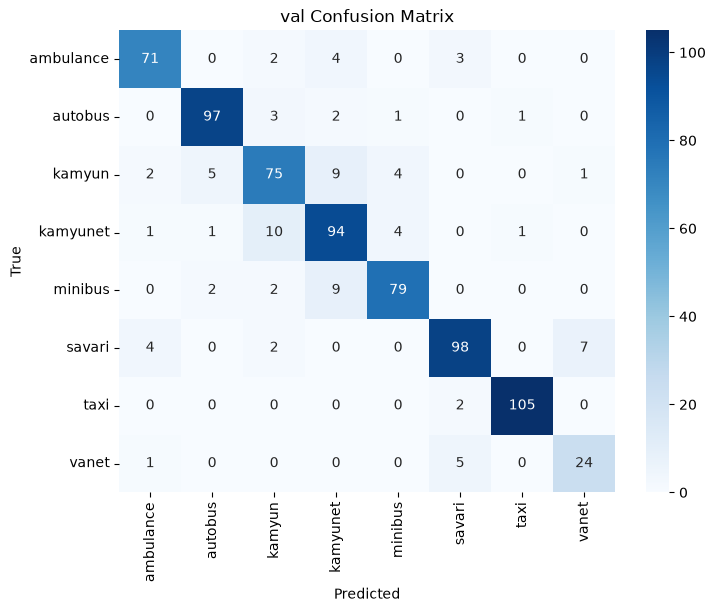

In [7]:
cm = confusion_matrix(
    all_val_labels,
    all_val_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("val Confusion Matrix")

plt.show()

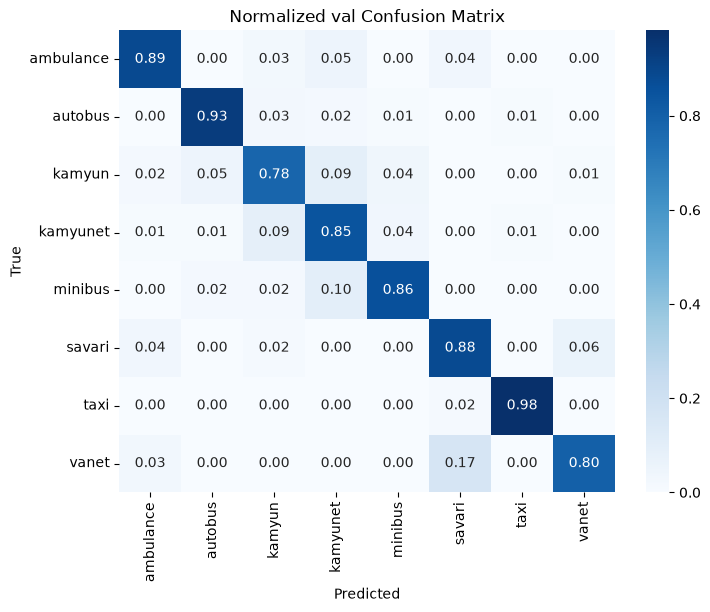

In [8]:
cm_normalized = confusion_matrix(
    all_val_labels,
    all_val_predictions,
    normalize="true"
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized val Confusion Matrix")

plt.show()